# EDA Notebook
## 1st dataset
For this first dataset [https://www.kaggle.com/datasets/utsav15/it-helpdesk/data](https://www.kaggle.com/datasets/utsav15/it-helpdesk/data), we'll keep the title column and then do some nlp on title.  We'll come back around and use the resolution for our FAQ/wiki pages.


In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix 

df = pd.read_csv('data/it_clean_data.csv')
df.head()

,Unnamed: 0.1,Unnamed: 0,Title,Resolution,class
0,0,0,Need Ethernet access,Please connect the LAN cable to the red port o...,41
1,1,1,Create new account and share the username and ...,"Go to URL : accountsetup.com, Enter personal d...",35
2,2,2,FW: Myspace Login Issue-- Ania,"Go to URL : password.reset.com, Enter you logi...",36
3,3,3,Login credetials are not working.,"Go to URL : password.reset.com, Enter you logi...",36
4,4,4,New Account is needed for a new joinee.,"Go to URL : accountsetup.com, Enter personal d...",35


In [78]:
# We're going to drop these columns as there was no documentation on what they were and they don't seem to be relevant to our analysis. 
df1 = df.drop(columns=['Unnamed: 0', 'Unnamed: 0.1','class'])

In [79]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       59 non-null     object
 1   Resolution  59 non-null     object
dtypes: object(2)
memory usage: 1.1+ KB


In [80]:
df1[['Title','Resolution']].head()

,Title,Resolution
0,Need Ethernet access,Please connect the LAN cable to the red port o...
1,Create new account and share the username and ...,"Go to URL : accountsetup.com, Enter personal d..."
2,FW: Myspace Login Issue-- Ania,"Go to URL : password.reset.com, Enter you logi..."
3,Login credetials are not working.,"Go to URL : password.reset.com, Enter you logi..."
4,New Account is needed for a new joinee.,"Go to URL : accountsetup.com, Enter personal d..."


In [81]:
# As we can see, there an Issue Type or label does not exist in this dataset. We'll use some NLP techniques to get the most
# commonly used word counts.  This will help us understand on how we can classify and label this dataset. 

# Getting the title, and checking for the most frequently used words.
# preprocess > remove punctuation, lowercase, remove stop words, lemmatize
# need to get the most commonly used keywords for classification
import re

all_title1 = ' '.join(df['Title'].astype(str))
all_title1 = all_title1.lower()
words = re.sub(r'[^\w\s]', '', all_title1)
print(len(words))
#print(words)

2364


In [82]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
import string

#nltk.download('punkt')
#nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
tokens_no_stop = [word for word in word_tokenize(words) if word not in stop_words]
print(len(tokens_no_stop))
print(tokens_no_stop)

fdist = FreqDist(tokens_no_stop)
df1_most_common = fdist.most_common(20)
df1_most_common

233
['need', 'ethernet', 'access', 'create', 'new', 'account', 'share', 'username', 'password', 'fw', 'myspace', 'login', 'issue', 'ania', 'login', 'credetials', 'working', 'new', 'account', 'needed', 'new', 'joinee', 'request', 'configure', 'system', 'share', 'among', 'users', 'needs', 'permission', 'wifi', 'access', 'laptop', 'lan', 'working', 'vm', 'wifi', 'access', 'needed', 'space', 'qa', 'application', 'configure', 'outlook', 'system', 'install', 'postgres', 'database', 'machine', 'system', 'showing', 'blue', 'screen', 'startup', 'desktop', 'working', 'system', 'behaving', 'strangely', 'blue', 'screen', 'appearing', 'middle', 'internet', 'working', 'account', 'got', 'locked', '3', 'wrong', 'attempts', 'os', 'password', 'could', 'please', 'reset', 'password', 'system', 'hangs', 'blue', 'screen', 'startup', 'unable', 'connect', 'internet', 'facing', 'networkinternet', 'issue', 'wifi', 'xwq090', 'replace', 'battery', 'macbook', 'laptop', 'computer', 'getting', 'switched', 'forgot', 

[('computer', 9),
 ('password', 7),
 ('working', 5),
 ('system', 5),
 ('screen', 5),
 ('account', 4),
 ('virus', 4),
 ('windows', 4),
 ('access', 3),
 ('new', 3),
 ('login', 3),
 ('wifi', 3),
 ('install', 3),
 ('blue', 3),
 ('internet', 3),
 ('email', 3),
 ('drive', 3),
 ('cant', 3),
 ('printer', 3),
 ('share', 2)]

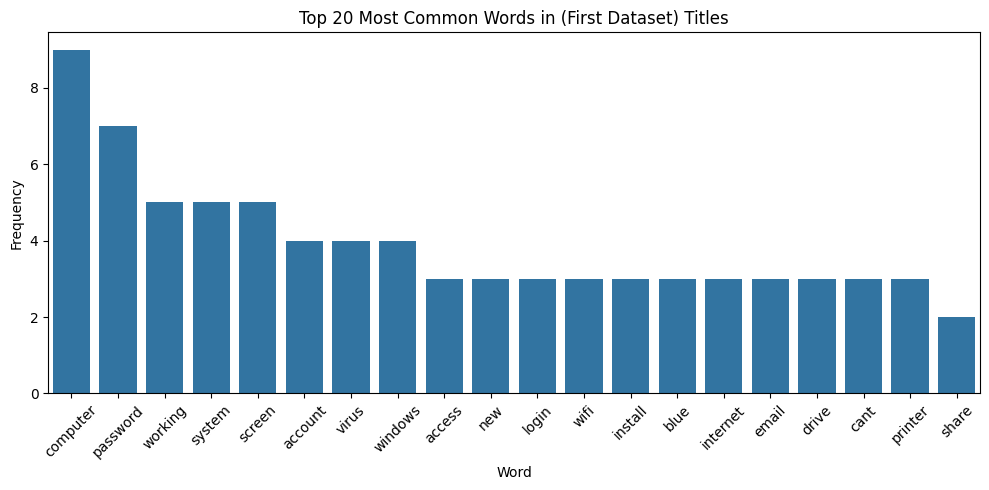

In [83]:
# Let's plot that
df1_most_common_df = pd.DataFrame(df1_most_common, columns=['Word', 'Frequency'])
plt.figure(figsize=(10, 5))
sns.barplot(x='Word', y='Frequency', data=df1_most_common_df)
plt.xticks(rotation=45)
plt.title('Top 20 Most Common Words in (First Dataset) Titles')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/df1_top_words.png')
plt.show()

In [84]:
# Check some of the phrases used in Title
df1[df1['Title'].str.contains('login', case=False, na=False)]

,Title,Resolution
2,FW: Myspace Login Issue-- Ania,"Go to URL : password.reset.com, Enter you logi..."
3,Login credetials are not working.,"Go to URL : password.reset.com, Enter you logi..."
26,Account locked. Not able to login,Unlocked the account and new password is sent ...


In [85]:
# Let's define our categories/label and create our target column ('Type'). 
"""
categories = [
    'password', 'system', 'account', 'access_request',
    'network', 'platform', 'hardware', 'software', 'security', 'other'
]
"""

keyword_map = {
    'password':       ['password', 'passwd', 'reset', 'forgot', 'login', 'credential','locked'],
    'security':       ['security', 'virus', 'malware', 'breach', 'phishing', 'firewall', 'threat','vulnerability','encryption','compliance','2fa','two factor','breach','firewall','phishing'],
    'hardware':       ['hardware', 'printer', 'monitor', 'keyboard', 'mouse', 'laptop', 'device','screen','need a','cable','connector','desktop','paper jam','hard disk','no signal'],
    'software':       ['software', 'install', 'update', 'upgrade', 'application', 'app', 'license','api','integration','export','configure','error message','not saving','feature'],
    'system':         ['system', 'computer', 'server', 'crash', 'reboot', 'outage', 'slow','windows','mac','machine'],
    'access_request': ['account', 'access request', 'permission', 'request', 'grant', 'role', 'privilege','newhire','username', 'user', 'deactivate','suspend','reactivate','profile'],
    'network':        ['network', 'wifi', 'internet', 'vpn', 'connection', 'connect','connectivity','bandwidth', 'dns','ethernet'],
    'platform':       ['platform', 'portal', 'dashboard', 'interface', 'vm', 'container','cloud'],
    'other':          []  # This will be our default/catch-all category for unmatched issues
}

def classify_issue(title):
    title = title.lower()
    for category, keyword in keyword_map.items():
        if category == 'other':
            continue
        if any(kw in title for kw in keyword):
            return category
    return 'other'

def label_dataset(df: pd.DataFrame, title_col: str = 'Title') -> pd.DataFrame:
    df['Type'] = df[title_col].apply(classify_issue)
    return df

df1_labeled = label_dataset(df1)
df1_labeled.head()

,Title,Resolution,Type
0,Need Ethernet access,Please connect the LAN cable to the red port o...,network
1,Create new account and share the username and ...,"Go to URL : accountsetup.com, Enter personal d...",password
2,FW: Myspace Login Issue-- Ania,"Go to URL : password.reset.com, Enter you logi...",password
3,Login credetials are not working.,"Go to URL : password.reset.com, Enter you logi...",password
4,New Account is needed for a new joinee.,"Go to URL : accountsetup.com, Enter personal d...",access_request


In [86]:
df1_labeled['Type'].value_counts()

Type
hardware          18
network            8
password           8
system             8
software           6
other              5
security           4
access_request     1
platform           1
Name: count, dtype: int64

In [87]:
df1_labeled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       59 non-null     object
 1   Resolution  59 non-null     object
 2   Type        59 non-null     object
dtypes: object(3)
memory usage: 1.5+ KB


## 2nd Dataset
Ok after initial EDA, we don't have many records/rows. Reviewed a few datasets, here's another one.  Unfortunately, these type of datasets may reveal PII or sensitive information about organizations so we'll have to make due.  Second dataset from [https://www.kaggle.com/datasets/utsav15/it-helpdesk/data](https://www.kaggle.com/datasets/utsav15/it-helpdesk/data), we'll clean and merge and see if the most frequent words are similar.

In [88]:
# Run once if not currently installed/present.
#!pip install openpyxl

In [89]:
it2 = pd.read_excel('data/SampleInput.xlsx')
it2.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,TicketNumber,Client,Staff,Source,Title,Resolution,HelpTopic,DataOn,DueDate,ClosedDate,ModifiedDate,KYC
1,T955496,User,ITSupport,Email,Need Ethernet access,Please connect the LAN cable to the red port o...,Network & Wireless,12/17/15 12:00 PM,NaN,12/17/15 01:02 PM,12/17/15 12:59 PM,YY
2,IT413956,User,ITSupport,Email,Need a LAN Cable,Please come to IT desk and collect.,Accessories,14-12-2017 12:06,NaN,15-12-2017 13:13,14-12-2017 12:42,N
3,IT413444,User,ITSupport,Email,Need a laptop Conector.,Please come to IT desk and collect.,Accessories,14-12-2017 12:06,NaN,15-12-2017 13:13,14-12-2017 13:44,N
4,IT413923,User,ITSupport,Email,Need a mouse,hello Raj Ganpur<br /><br />please come to It ...,Accessories,14-12-2017 12:06,NaN,15-12-2017 13:13,15-12-2017 12:15,N


In [90]:
it2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399 entries, 0 to 398
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   399 non-null    object
 1   Unnamed: 1   399 non-null    object
 2   Unnamed: 2   399 non-null    object
 3   Unnamed: 3   399 non-null    object
 4   Unnamed: 4   274 non-null    object
 5   Unnamed: 5   399 non-null    object
 6   Unnamed: 6   399 non-null    object
 7   Unnamed: 7   399 non-null    object
 8   Unnamed: 8   1 non-null      object
 9   Unnamed: 9   399 non-null    object
 10  Unnamed: 10  399 non-null    object
 11  Unnamed: 11  395 non-null    object
dtypes: object(12)
memory usage: 37.5+ KB


In [91]:
# Lets subset this data to just the columns we need. 
# The date fields, ticket numbers, tags, etc..are not releavant to our analysis.
it3  = it2[['Unnamed: 4','Unnamed: 5','Unnamed: 6']]
it3.head()


,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Title,Resolution,HelpTopic
1,Need Ethernet access,Please connect the LAN cable to the red port o...,Network & Wireless
2,Need a LAN Cable,Please come to IT desk and collect.,Accessories
3,Need a laptop Conector.,Please come to IT desk and collect.,Accessories
4,Need a mouse,hello Raj Ganpur<br /><br />please come to It ...,Accessories


In [92]:
# Let's rename the columns and reset the index. Then drop the first 2 columns.
it3.columns = it3.iloc[0]
it3 = it3.iloc[1:].reset_index(drop=True)
it3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       273 non-null    object
 1   Resolution  398 non-null    object
 2   HelpTopic   398 non-null    object
dtypes: object(3)
memory usage: 9.5+ KB


In [93]:
# The good thing about this dataset is it has our target column already. Rename the target column:
it3.rename(columns={'HelpTopic': 'Type'}, inplace=True)
it3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       273 non-null    object
 1   Resolution  398 non-null    object
 2   Type        398 non-null    object
dtypes: object(3)
memory usage: 9.5+ KB


In [94]:
# Let's drop the null values, as the Title column is essential for our analysis. 
it3 = it3.dropna(subset=['Title'])
it3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 273 entries, 0 to 397
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       273 non-null    object
 1   Resolution  273 non-null    object
 2   Type        273 non-null    object
dtypes: object(3)
memory usage: 8.5+ KB


In [95]:
# Unfortunately, there are some values that are more ticket statuses vs actualy ticket title/subjects.
invalid_titles = ['Status Changed','Collaborators added by end user','Ticket Marked Overdue','Ticket Updated','Ticket Assigned to Sandeep Reddy Jakkidi','Ticket Assigned to Shijil Kumar Aynoli','Ticket Assigned to Pavan Kumar Thukuntla','Ticket Assigned to Shashi Kumar Raju Hasthi', 'Ticket Assigned to Kishore Babu Ganesana', 'Ticket Assigned to N V R S Surya Narayana Garlapati','New Collaborator Added', 'Ticket Assigned to Janardhana Rao Vemulapalli','Ticket Assigned to Nagaraju Mochi', 'Ticket Assigned to Vinod Kumar Reddy Dendi', 'New Ticket by Agent','Ticket Assigned to Anil Kumar Thanjavuru']
it3 = it3[~it3['Title'].isin(invalid_titles)]
it3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 0 to 397
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       65 non-null     object
 1   Resolution  65 non-null     object
 2   Type        65 non-null     object
dtypes: object(3)
memory usage: 2.0+ KB


In [96]:
it3['Type'].value_counts()

Type
Access Requests                          31
Network & Wireless                        7
Accessories                               7
Hardware Issue                            3
Data Center Services /Report VM issue     2
Software Request                          2
Email Services                            2
Hardware                                  2
Network                                   2
VPN access                                1
Jira Requests                             1
Data Center Services                      1
Data Center Services /VM Request          1
Newhire Accounts                          1
Password Reset                            1
Software Installation & Configuration     1
Name: count, dtype: int64

In [97]:
# This second dataset is really unbalanced with the majority of the data classifying as 'Access Requests' or 'Accessories'.  
# The Types in this dataset closely align with our mapping.  Let's rename them.
it3['Type'] = it3['Type'].replace({
    'Access Requests': 'access_request',
    'Accessories': 'hardware',
    'Network & Wireless': 'network',
    'Hardware Issue': 'hardware',
    'Data Center Services /Report VM issue': 'platform',
    'Data Center Services': 'platform',
    'Data Center Services /VM Request': 'platform',
    'Software Rquest': 'software',
    'Email Services': 'other',
    'Hardware': 'hardware',
    'Network': 'network',
    'VPN access': 'network',
    'Jira Requests': 'software',
    'Newhire Accounts': 'access_request',
    'Password Reset': 'password',
    'Software Installation & Configuration': 'software',
    'Software Request': 'software'
})


In [98]:
#Let's double check 
it3['Type'].value_counts()

Type
access_request    32
hardware          12
network           10
software           4
platform           4
other              2
password           1
Name: count, dtype: int64

In [99]:
# Oh no! Some ticket titles were more of ticket status updates, so we will remove those.
# Removing these, and after all the data cleaning, we have significantly less data to work with. 
invalid_titles = ['Status Changed','Collaborators added by end user','Ticket Marked Overdue','Ticket Updated','Ticket Assigned to Sandeep Reddy Jakkidi','Ticket Assigned to Shijil Kumar Aynoli','Ticket Assigned to Pavan Kumar Thukuntla','Ticket Assigned to Shashi Kumar Raju Hasthi', 'Ticket Assigned to Kishore Babu Ganesana', 'Ticket Assigned to N V R S Surya Narayana Garlapati','New Collaborator Added', 'Ticket Assigned to Janardhana Rao Vemulapalli','Ticket Assigned to Nagaraju Mochi', 'Ticket Assigned to Vinod Kumar Reddy Dendi', 'New Ticket by Agent','Ticket Assigned to Anil Kumar Thanjavuru']
it3 = it3[~it3['Title'].isin(invalid_titles)]
it3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 65 entries, 0 to 397
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       65 non-null     object
 1   Resolution  65 non-null     object
 2   Type        65 non-null     object
dtypes: object(3)
memory usage: 2.0+ KB


In [100]:
# Let's rename our it3 df to be consistent, then concat our two datasets together and see if we can find any insights.
df2_labeled = it3
it_clean = pd.concat([df1_labeled, df2_labeled], ignore_index=True)
it_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       124 non-null    object
 1   Resolution  124 non-null    object
 2   Type        124 non-null    object
dtypes: object(3)
memory usage: 3.0+ KB


In [101]:
it_clean.head()

,Title,Resolution,Type
0,Need Ethernet access,Please connect the LAN cable to the red port o...,network
1,Create new account and share the username and ...,"Go to URL : accountsetup.com, Enter personal d...",password
2,FW: Myspace Login Issue-- Ania,"Go to URL : password.reset.com, Enter you logi...",password
3,Login credetials are not working.,"Go to URL : password.reset.com, Enter you logi...",password
4,New Account is needed for a new joinee.,"Go to URL : accountsetup.com, Enter personal d...",access_request


In [102]:
# Ok now let's check the value counts 
it_clean['Type'].value_counts()

Type
access_request    33
hardware          30
network           18
software          10
password           9
system             8
other              7
platform           5
security           4
Name: count, dtype: int64

In [103]:
# Double check for certain text in the title and check for phrases
it_clean[it_clean['Title'].str.contains('Status', case=False, na=False)].count()

Title         0
Resolution    0
Type          0
dtype: int64

In [104]:
# We dont' want any NULL titles, so we'll drop those.  
# Then we'll follow the same process and before to see if it made a difference in the most commonly used words.
it_all_titles = ' '.join(it_clean['Title'].dropna().astype(str))
it_all_titles = it_all_titles.lower()
it_all_titles_clean = re.sub(r'[^\w\s]', '', it_all_titles)
print(len(it_all_titles_clean))

# Tokenize the titles and remove stop words.
tokens_no_stop2 = [word for word in word_tokenize(it_all_titles_clean) if word not in stop_words]
print(len(tokens_no_stop2))
print(tokens_no_stop2)

# Let's get frequency counts
fdist2 = FreqDist(tokens_no_stop2)
df2_most_common = fdist2.most_common(20)
df2_most_common

4734
517
['need', 'ethernet', 'access', 'create', 'new', 'account', 'share', 'username', 'password', 'fw', 'myspace', 'login', 'issue', 'ania', 'login', 'credetials', 'working', 'new', 'account', 'needed', 'new', 'joinee', 'request', 'configure', 'system', 'share', 'among', 'users', 'needs', 'permission', 'wifi', 'access', 'laptop', 'lan', 'working', 'vm', 'wifi', 'access', 'needed', 'space', 'qa', 'application', 'configure', 'outlook', 'system', 'install', 'postgres', 'database', 'machine', 'system', 'showing', 'blue', 'screen', 'startup', 'desktop', 'working', 'system', 'behaving', 'strangely', 'blue', 'screen', 'appearing', 'middle', 'internet', 'working', 'account', 'got', 'locked', '3', 'wrong', 'attempts', 'os', 'password', 'could', 'please', 'reset', 'password', 'system', 'hangs', 'blue', 'screen', 'startup', 'unable', 'connect', 'internet', 'facing', 'networkinternet', 'issue', 'wifi', 'xwq090', 'replace', 'battery', 'macbook', 'laptop', 'computer', 'getting', 'switched', 'forg

[('password', 15),
 ('login', 12),
 ('system', 11),
 ('working', 10),
 ('computer', 10),
 ('need', 9),
 ('access', 9),
 ('wifi', 9),
 ('install', 9),
 ('account', 8),
 ('screen', 8),
 ('new', 7),
 ('needed', 7),
 ('internet', 7),
 ('unable', 7),
 ('blue', 6),
 ('file', 6),
 ('myspace', 5),
 ('laptop', 5),
 ('outlook', 5)]

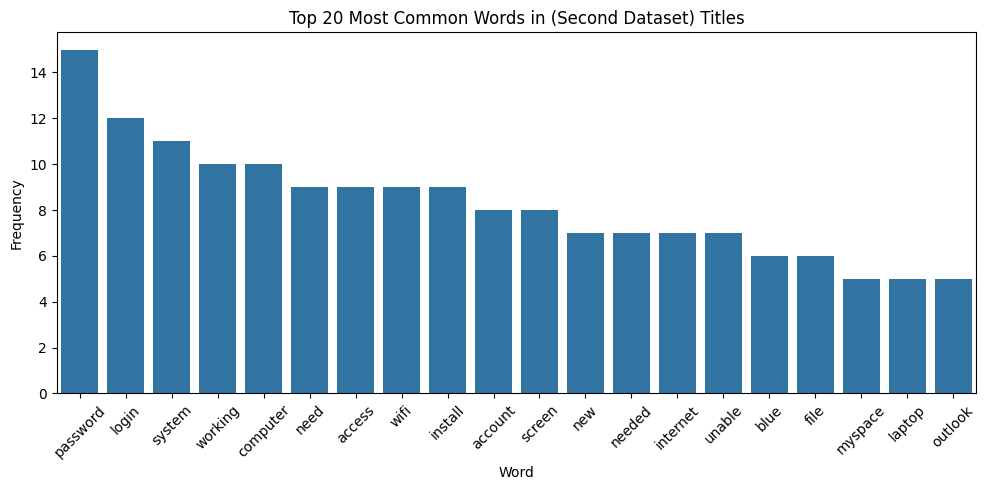

In [105]:
# Let's plot that
df2_most_common_df = pd.DataFrame(df2_most_common, columns=['Word', 'Frequency'])
plt.figure(figsize=(10, 5))
sns.barplot(x='Word', y='Frequency', data=df2_most_common_df)
plt.xticks(rotation=45)
plt.title('Top 20 Most Common Words in (Second Dataset) Titles')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/df2_top_words.png')
plt.show()

In [106]:
# check the df before modeling
it_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124 entries, 0 to 123
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       124 non-null    object
 1   Resolution  124 non-null    object
 2   Type        124 non-null    object
dtypes: object(3)
memory usage: 3.0+ KB


In [107]:
it_clean['Type'].value_counts()

Type
access_request    33
hardware          30
network           18
software          10
password           9
system             8
other              7
platform           5
security           4
Name: count, dtype: int64

In [108]:
# Let's see what our model looks like with the merged dataset.
X = it_clean['Title']
y = it_clean['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        stop_words="english",
        ngram_range=(1,2),
    )),
    ('clf', LogisticRegression(max_iter=100, random_state=42))
])
pipeline.fit(X_train,y_train)



,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [109]:
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred, zero_division=0))

                precision    recall  f1-score   support

access_request       0.44      0.57      0.50         7
      hardware       0.42      0.83      0.56         6
       network       1.00      0.25      0.40         4
         other       0.00      0.00      0.00         1
      password       0.00      0.00      0.00         2
      platform       0.00      0.00      0.00         1
      security       0.00      0.00      0.00         1
      software       1.00      0.50      0.67         2
        system       0.50      1.00      0.67         1

      accuracy                           0.48        25
     macro avg       0.37      0.35      0.31        25
  weighted avg       0.48      0.48      0.42        25



In [110]:
# From the metrics/classification report above there are some classes that are not being predicted at all.  
# From our last value_count there is one class that did not have data.
# It's a relatively small dataset, with some classes only having one row to support.
print("Classes in y_test:  ", np.unique(y_test))

Classes in y_test:   ['access_request' 'hardware' 'network' 'other' 'password' 'platform'
 'security' 'software' 'system']


In [111]:
print("Classes in y_pred:  ", np.unique(y_pred)) 

Classes in y_pred:   ['access_request' 'hardware' 'network' 'software' 'system']


Obviously, we've got some work to do here.  So let's incorporate a 3rd dataset,  but first, let's take a moment to recap where we are. 

Our first dataset, contained a title and resolution, but no classification. 
Based on domain knowledge, we created a list of predetermined categories and applied this to our first dataset.

Our second dataset - after EDA and cleaning, became relatively small.  However, it contained a target column.  Those values closely aligned with our target class values so we renamed them to match.  

Our first and second dataset was combined, but there wasn't enough data across all categories to make me comfortable saying we have a good initial base model.

## A third dataset. 
Source: https://www.kaggle.com/datasets/ahsanneural/synthetic-it-support-tickets

In [112]:
df3 = pd.read_csv('data/synthetic_it_support_tickets.csv')
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ticket_id              100000 non-null  object 
 1   created_at             100000 non-null  object 
 2   customer_id            100000 non-null  object 
 3   customer_segment       100000 non-null  object 
 4   channel                100000 non-null  object 
 5   product_area           100000 non-null  object 
 6   issue_type             100000 non-null  object 
 7   priority               100000 non-null  object 
 8   status                 100000 non-null  object 
 9   sla_plan               100000 non-null  object 
 10  initial_message        100000 non-null  object 
 11  agent_first_reply      100000 non-null  object 
 12  resolution_summary     60113 non-null   object 
 13  resolution_time_hours  60113 non-null   float64
 14  reopened               100000 non-nul

In [113]:
df3.head()

,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA
3,TCKT_000004,2025-12-25T15:59:52,CUST_03557,education,chat,analytics_dashboard,account_access,medium,in_progress,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,NaN,NaN,0,positive,5,1,android,LATAM
4,TCKT_000005,2023-08-27T16:08:33,CUST_09556,enterprise,phone_transcript,login_auth,billing_problem,low,resolved,gold,My invoice amount is incorrect compared to the...,Thanks for reaching out about the billing issu...,Adjusted the invoice and issued a refund where...,61.32,0,very_negative,2,0,web,NaN


In [114]:
# Let's subset the data to just the columns we need. Then rename columns.
itdf3 = df3[['initial_message', 'resolution_summary', 'issue_type']].copy()
itdf3.rename(columns={'initial_message': 'Title'}, inplace=True)
itdf3.rename(columns={'resolution_summary': 'Resolution'}, inplace=True)
itdf3.rename(columns={'issue_type': 'Type'}, inplace=True)
itdf3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Title       100000 non-null  object
 1   Resolution  60113 non-null   object
 2   Type        100000 non-null  object
dtypes: object(3)
memory usage: 2.3+ MB


In [115]:
itdf3['Type'].value_counts()

Type
how_to              12739
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
billing_problem     12382
bug                 12349
Name: count, dtype: int64

In [116]:
# There are a few types we are not interested in, since the intent is for this to be used internally for IT support tickets. 
# Let's drop the how_to and billing_problem types. 
itdf = itdf3[~itdf3['Type'].isin(['how_to', 'billing_problem'])]

# double check
print(itdf['Type'].value_counts())

# I noticed some duplicate titles so let's drop those too
itdf = itdf.drop_duplicates(subset=['Title'])

# Unfortunately, there were many duplicate titles that caused a huge imbalance in data
itdf.info()

Type
account_access      12609
performance         12513
feature_request     12487
other               12463
security_concern    12458
bug                 12349
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 72 entries, 0 to 1097
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       72 non-null     object
 1   Resolution  45 non-null     object
 2   Type        72 non-null     object
dtypes: object(3)
memory usage: 2.2+ KB


In [117]:
df_model = itdf.copy()
print(f"df_model : {len(df_model)}")

df_final = pd.concat([df_model, it_clean], ignore_index=True)


df_model : 72


In [118]:
# Let's apply our labels to our dataset
df_final_relabeled = label_dataset(df_final)
df_final_relabeled.head()
df_final_relabeled['Type'].value_counts()

df_final_relabeled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       196 non-null    object
 1   Resolution  169 non-null    object
 2   Type        196 non-null    object
dtypes: object(3)
memory usage: 4.7+ KB


In [119]:
# Let's check word frequencies in this new dataset.
df3_relabeled = ' '.join(df_final_relabeled['Title'].dropna().astype(str))
df3_relabeled= df3_relabeled.lower()
df3_relabeled_clean = re.sub(r'[^\w\s]', '', df3_relabeled)
print(len(df3_relabeled_clean))

# Tokenize the titles and remove stop words.
tokens_no_stop3 = [word for word in word_tokenize(df3_relabeled_clean) if word not in stop_words]
print(len(tokens_no_stop3))
print(tokens_no_stop3)

# Let's get frequency counts
fdist3 = FreqDist(tokens_no_stop3)
df3_most_common = fdist3.most_common(20)
df3_most_common

8912
928
['log', 'system', 'says', 'password', 'incorrect', 'noticed', 'suspicious', 'login', 'account', 'api', 'integration', 'feature', 'saving', 'changes', 'queries', 'mobile', 'app', 'module', 'timing', 'overall', 'performance', 'degraded', 'last', 'days', 'team', 'needs', 'advanced', 'options', 'data', 'export', 'data', 'export', 'page', 'slow', 'takes', 'long', 'time', 'load', 'would', 'great', 'mobile', 'app', 'support', 'product', 'need', 'details', 'data', 'encryption', 'compliance', 'page', 'keeps', 'crashing', 'whenever', 'try', 'open', 'billing', 'section', '2fa', 'code', 'working', 'try', 'sign', 'team', 'needs', 'advanced', 'options', 'api', 'integration', 'add', 'option', 'customize', 'login', 'auth', 'page', 'keeps', 'crashing', 'whenever', 'try', 'open', 'login', 'auth', 'section', 'account', 'locked', 'multiple', 'failed', 'login', 'attempts', 'general', 'question', 'account', 'billing', 'page', 'slow', 'takes', 'long', 'time', 'load', 'would', 'great', 'notifications

[('login', 23),
 ('page', 17),
 ('password', 16),
 ('system', 12),
 ('account', 11),
 ('need', 11),
 ('working', 11),
 ('error', 11),
 ('data', 10),
 ('computer', 10),
 ('api', 9),
 ('integration', 9),
 ('mobile', 9),
 ('app', 9),
 ('needs', 9),
 ('export', 9),
 ('billing', 9),
 ('auth', 9),
 ('notifications', 9),
 ('analytics', 9)]

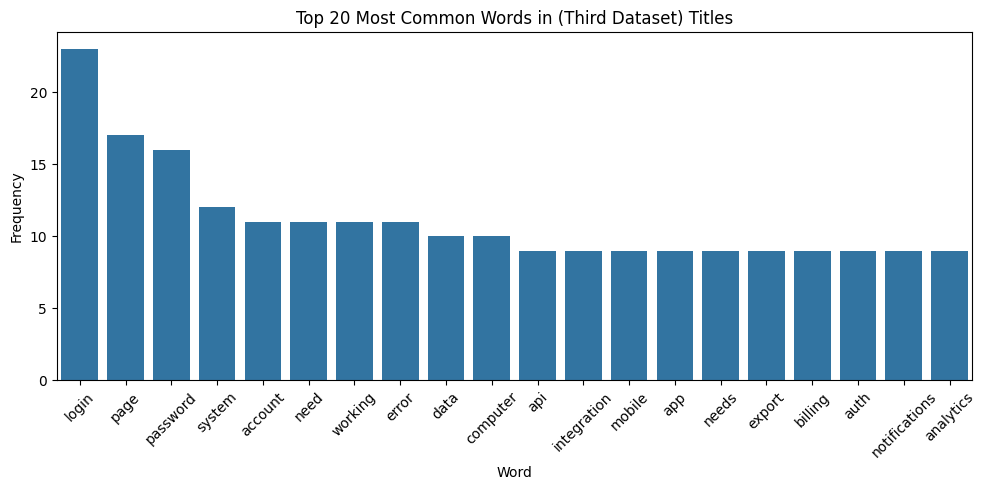

In [120]:
# Let's plot that
df3_most_common_df = pd.DataFrame(df3_most_common, columns=['Word', 'Frequency'])
plt.figure(figsize=(10, 5))
sns.barplot(x='Word', y='Frequency', data=df3_most_common_df)
plt.xticks(rotation=45)
plt.title('Top 20 Most Common Words in (Third Dataset) Titles')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/df3_top_words.png')
plt.show()

# 4. A fourth model
After modeling, and comparison - we found that our 3rd dataset contained duplicates and could have impacted the weights on our model.  So yet we're incorporting another dataset.  

Source: [https://huggingface.co/datasets/Console-AI/IT-helpdesk-synthetic-tickets/tree/main](https://huggingface.co/datasets/Console-AI/IT-helpdesk-synthetic-tickets/tree/main)

In [121]:
df4 = pd.read_csv('data/tickets.csv')
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              500 non-null    object
 1   subject         500 non-null    object
 2   description     500 non-null    object
 3   priority        500 non-null    object
 4   category        500 non-null    object
 5   createdAt       500 non-null    object
 6   requesterEmail  500 non-null    object
dtypes: object(7)
memory usage: 27.5+ KB


In [122]:
# ok subset and only keep the coluns we need. Then we'll apply our labels to this dataset and see how it looks.
df4a = df4[['subject', 'category']].copy()

# let's get rid of duplicates
df4a.drop_duplicates(subset=['subject'], inplace=True)
df4a.info()

<class 'pandas.core.frame.DataFrame'>
Index: 489 entries, 0 to 499
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   489 non-null    object
 1   category  489 non-null    object
dtypes: object(2)
memory usage: 11.5+ KB


In [123]:
# Let's check out the value counts for the category column. 
df4a['category'].value_counts()

category
Software          230
Account            71
Network            65
Security           36
Communication      24
Hardware           22
RemoteWork         19
Training           12
Infrastructure      7
Licensing           2
Performance         1
Name: count, dtype: int64

In [124]:
#Let's check some of the categories that are labeled differently and see if they align with our mapping.
df4a.query("category == 'Infrastructure'") # This will map to platform
df4a.query("category == 'Performance'") # This will map to software
df4a.query("category == 'Communication'") # Some of these will map to access, or software, or other depending on the title. 
df4a.query("category == 'RemoteWork'") # Most of these will map to software, or network
df4a.query("category == 'Licensing'") # These will map to software
df4a.query("category == 'Training'") # These will map to various categories 

,subject,category
8,Intranet Navigation Assistance,Training
16,Google Calendar Setup Instructions,Training
80,Instructions for Creating a New Google Calenda...,Training
157,Phishing Email Reporting Instructions,Training
224,Need help with leave request submission,Training
246,Re: Request for Instructions: Creating a New G...,Training
307,Dual Monitor Display Configuration Instructions,Training
308,Reset Password for Online Training Portal,Training
340,Instructions for Submitting a Project Proposal,Training
346,Requesting Instructions for Email Signature Setup,Training


In [125]:
# Ok, now we know where these will map to, let's rename the columns.
df4a.rename(columns={'subject': 'Title'}, inplace=True)
df4a.rename(columns={'category': 'Type'}, inplace=True)

In [126]:
# Let's check word frequencies in this new dataset.
df4a_relabeled = ' '.join(df4a['Title'].dropna().astype(str))
df4a_relabeled = df4a_relabeled.lower()
df4a_relabeled = re.sub(r'[^\w\s]', '', df4a_relabeled)
print(len(df4a_relabeled))

# Tokenize the titles and remove stop words.
tokens_no_stop4 = [word for word in word_tokenize(df4a_relabeled) if word not in stop_words]
print(len(tokens_no_stop4))
print(tokens_no_stop4)

# Let's get frequency counts
fdist4 = FreqDist(tokens_no_stop4)
df4_most_common = fdist4.most_common(20)
df4_most_common

23554
2689
['hey', 'network', 'printer', 'keeps', 'disconnecting', 'acme', 'ticket', '98765', 'access', 'issue', 'shared', 'network', 'drive', 'software', 'conflict', 'causing', 'app', 'crashes', 'jdoeacmeco', 'google', 'calendar', 'setup', 'assistance', 'software', 'access', 'asana', 'project', 'jordan', 'smith', 'email', 'client', 'sync', 'issue', 'access', 'request', 'db', 'storage', 'folder', 'johndoeacmeco', 'assistance', 'needed', 'password', 'reset', 'email', 'account', 'intranet', 'navigation', 'assistance', 'workstation', 'security', 'configuration', 'inconsistent', 'application', 'group', 'policies', 'persistent', 'authentication', 'failures', 'mfa', 'jira', 'board', 'access', 'request', 'alert', 'inconsistent', 'vpn', 'connectivity', 'network', 'analysis', 'required', 'access', 'issue', 'internal', 'web', 'application', 'browser', 'compatibility', 'software', 'license', 'activation', 'failures', 'slack', 'workspace', 'access', 'request', 'google', 'calendar', 'setup', 'instr

[('access', 178),
 ('request', 130),
 ('issues', 70),
 ('issue', 63),
 ('instructions', 58),
 ('email', 47),
 ('cloud', 44),
 ('assistance', 37),
 ('setup', 36),
 ('data', 36),
 ('system', 35),
 ('required', 32),
 ('intermittent', 31),
 ('failures', 28),
 ('persistent', 27),
 ('platform', 26),
 ('new', 24),
 ('authentication', 23),
 ('alert', 23),
 ('troubleshooting', 23)]

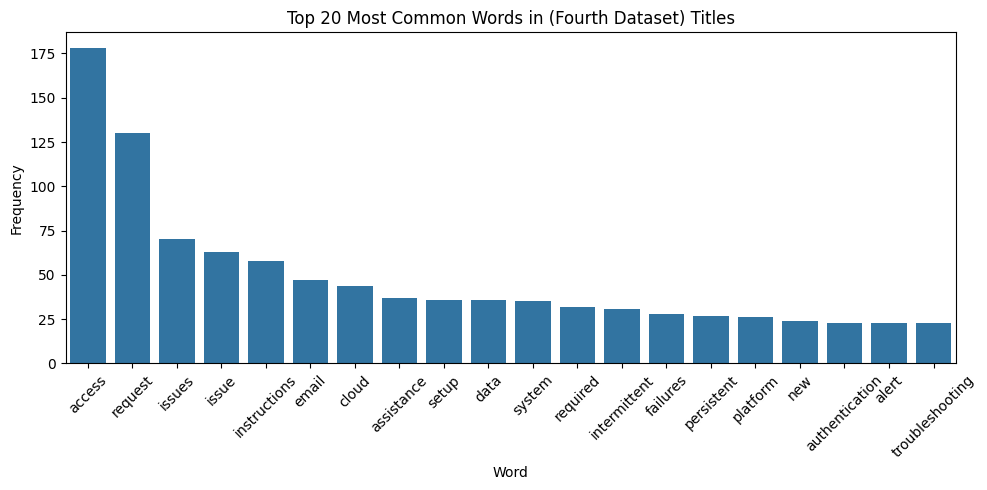

In [127]:
# Let's plot that
df4_most_common_df = pd.DataFrame(df4_most_common, columns=['Word', 'Frequency'])
plt.figure(figsize=(10, 5))
sns.barplot(x='Word', y='Frequency', data=df4_most_common_df)
plt.xticks(rotation=45)
plt.title('Top 20 Most Common Words in (Fourth Dataset) Titles')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('images/df4_top_words.png')
plt.show()

In [128]:
# ok let's apply our mapping and review
df4b_relabeled = label_dataset(df4a)
df4b_relabeled.head(10)


,Title,Type
0,Hey IT! Our network printer keeps disconnecting.,hardware
1,Re: [Acme IT] Re: Ticket #98765 - Access Issue...,network
2,Software Conflict Causing App Crashes,software
3,j.doe@acme.co Google Calendar Setup Assistance,other
4,Software Access: Asana Project for Jordan Smith,software
5,Email client sync issue,other
6,Access Request: DB Storage Folder - john.doe@a...,access_request
7,Assistance Needed: Password Reset for Email Ac...,password
8,Intranet Navigation Assistance,other
9,Workstation Security Configuration: Inconsiste...,security


In [129]:
df4b_relabeled['Type'].value_counts()

Type
access_request    126
other              97
software           58
hardware           57
system             45
platform           42
security           25
network            21
password           18
Name: count, dtype: int64

In [130]:
df_final.head()

,Title,Resolution,Type
0,I cannot log in; the system says my password i...,Reset account credentials and confirmed succes...,password
1,I noticed a suspicious login on my account.,Ticket closed without further action after no ...,password
2,The api integration feature is not saving my c...,NaN,software
3,Queries in the mobile app module are timing out.,Ticket closed without further action after no ...,software
4,Overall performance has degraded in the last f...,Optimized queries and increased resource alloc...,other


In [131]:
df4b_relabeled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 489 entries, 0 to 499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   489 non-null    object
 1   Type    489 non-null    object
dtypes: object(2)
memory usage: 11.5+ KB


In [132]:
df_final2 = pd.concat([df_final_relabeled, df4b_relabeled], ignore_index=True)

In [133]:
df_final2.head()

,Title,Resolution,Type
0,I cannot log in; the system says my password i...,Reset account credentials and confirmed succes...,password
1,I noticed a suspicious login on my account.,Ticket closed without further action after no ...,password
2,The api integration feature is not saving my c...,NaN,software
3,Queries in the mobile app module are timing out.,Ticket closed without further action after no ...,software
4,Overall performance has degraded in the last f...,Optimized queries and increased resource alloc...,other


In [134]:
df_final2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 685 entries, 0 to 684
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Title       685 non-null    object
 1   Resolution  169 non-null    object
 2   Type        685 non-null    object
dtypes: object(3)
memory usage: 16.2+ KB


# Persisting our data and and initial model

In [135]:
# Write out our final dataframe to a pickle file for our modeling and analysis.
df_final2.to_pickle('data/capstone.pkl')


In [136]:
# We're going to go with Naive Bayes as our baseline model. 
from sklearn.naive_bayes import MultinomialNB
X = df_final2['Title']
y = df_final2['Type']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
base = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])
base.fit(X_train,y_train)
y_pred_base = base.predict(X_test)
print(classification_report(y_test, y_pred_base, zero_division=0))


                precision    recall  f1-score   support

access_request       0.61      0.85      0.71        26
      hardware       0.74      0.78      0.76        18
       network       0.50      0.14      0.22         7
         other       0.47      0.64      0.54        25
      password       1.00      0.64      0.78        11
      platform       1.00      0.40      0.57        10
      security       0.67      0.29      0.40         7
      software       0.56      0.71      0.62        21
        system       0.80      0.33      0.47        12

      accuracy                           0.62       137
     macro avg       0.70      0.53      0.56       137
  weighted avg       0.67      0.62      0.61       137

